# 💾 11 · 离线强化学习 Offline RL：只许看录像，不许踩油门（BCQ / CQL / IQL）

> 面试定位：**Offline RL（离线强化学习/批式强化学习）** 是 2023-2025 算法岗的新兴高频考点——
> 大模型时代的 RLHF 数据、推荐系统日志、自动驾驶路采数据全是"静态数据集"。
> 知识链：10 篇解决"试错太贵"（脑内模拟）；本篇解决更狠的场景——**连"试"的机会都没有**，
> 只有别人留下的一堆历史数据。标记：🔴 必背 / 🟡 掌握 / 🟢 了解。

---

## 1. 完整介绍：什么是离线强化学习（🔴 0 基础也能懂）

### 通俗例子

- **看录像学开车**：你只有老司机开车的行车记录仪（一堆 $(状态, 动作, 结果)$ 数据），
  **不能亲自上路试**（不许踩油门、不许打方向去试探），就要学会开车
- **推荐系统**：你有用户历史点击日志，但**不能随便给用户推奇怪的内容做实验**
- **机器人手术**：手术记录有一堆，但你不能让机器人"试错"

### 与在线 RL 的根本区别（🔴 定义）

| | 在线 RL（00-10 篇） | 离线 RL（本篇） |
|---|---|---|
| 数据从哪来 | 智能体边学边采（自己探索） | **固定数据集**（别人采好的） |
| 能否试错 | 能（探索是合法的） | **不能**（数据外的动作永不出现） |
| 核心难题 | 探索-利用平衡 | **分布偏移（distribution shift）** |

> 一句话：**在线 RL 自己开车收集数据，离线 RL 看别人录像学开车——而且考试时就开真车。**

### 问题出在哪（🔴 直觉）

训练时 Q 网络只看过**数据里的动作**；一旦策略学偏，推理时输出一个**数据里没出现过的动作**，
Q 网络对它没有依据地"外推"打分——经常给出**虚高的 Q**。于是策略专门挑被高估的动作，
越学越偏（自举恶性循环）。这就是**外推误差（extrapolation error）**。

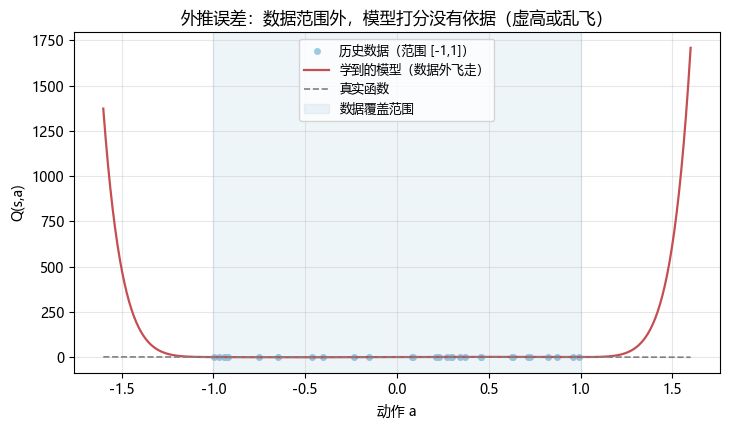

拟合误差：数据范围内 0.0354 vs 范围外 245.0871（外推被高次项带飞 → Q 不可信）
→ 离线 RL 的第一性难题：数据范围外的动作，Q 值全是"编的"


In [1]:
# ========== 外推误差的直觉演示：多项式拟合在数据范围外"飞走" ==========
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
rng = np.random.default_rng(0)
x = rng.uniform(-1, 1, 30)                       # 数据只覆盖 [-1, 1]
y = np.sin(3 * x) + 0.05 * rng.normal(size=30)
coef = np.polyfit(x, y, 12)                      # 高次多项式拟合（回忆"过拟合越界更疯"）
xx = np.linspace(-1.6, 1.6, 500)
yy = np.polyval(coef, xx)
in_d = np.abs(xx) <= 1.0
err_in = np.abs(yy[in_d] - np.sin(3 * xx[in_d])).mean()
err_out = np.abs(yy[~in_d] - np.sin(3 * xx[~in_d])).mean()

fig, ax = plt.subplots(figsize=(7.4, 4.4))
ax.scatter(x, y, s=16, color='#9ecae1', label='历史数据（范围 [-1,1]）')
ax.plot(xx, yy, lw=1.6, color='#C44E52', label='学到的模型（数据外飞走）')
ax.plot(xx, np.sin(3 * xx), '--', lw=1.2, color='gray', label='真实函数')
ax.axvspan(-1, 1, color='#3182bd', alpha=0.08, label='数据覆盖范围')
ax.set_xlabel('动作 a'); ax.set_ylabel('Q(s,a)')
ax.set_title('外推误差：数据范围外，模型打分没有依据（虚高或乱飞）', fontsize=12)
ax.legend(fontsize=9); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()
print('拟合误差：数据范围内 %.4f vs 范围外 %.4f（外推被高次项带飞 → Q 不可信）' % (err_in, err_out))
assert err_out > err_in * 3
print('→ 离线 RL 的第一性难题：数据范围外的动作，Q 值全是"编的"')

### 把"分布偏移"写进数学（🔴 深入）

**设定**：行为策略 $\beta$ 采了静态数据集 $\mathcal{D}=\{(s,a,r,s')\}$；
我们学的策略是 $\pi$。分布偏移的数学面孔有两个：

**① 动作分布错位（策略 mismatch）**：
$$\text{训练见到的动作分布}\ \pi_\beta(a|s) \;\neq\; \text{执行时的}\ \pi(a|s)$$
Q 只在 $\pi_\beta$ 采过的 $(s,a)$ 上有监督；$\pi$ 一旦"出圈"，Q 靠外推打分。

**② 外推误差的放大公式（直觉）**：
对数据外的动作 $a\notin \text{supp}(\mathcal{D})$，
$$Q_{\text{new}}(s,a) \approx Q_{\text{old}}(s,a) + \text{（无监督的外推噪声）}$$
且 $\max_a$ 专门挑噪声**上偏**的动作 → 虚高随训练轮数**自举放大**（03/04 篇的
最大化偏差在离线场景下变成"无数据约束的高估"）。

**为什么在线 RL 不受这伤**：在线时动作是策略自己采的，即使 Q 高估，
马上就能"实地验证"修正；**离线时永远没人验证** → 错误估计焊死在数据集上。

> 一句话：**离线 RL 的病根 = 训练分布 ≠ 执行分布，且没有"实地纠错"的机会；**
> **BCQ/CQL/IQL 三兄弟分别用"约束动作 / 压低 Q / 只学数据内分位"来治它。**

---


## 2. 三大困难与解决思路总览（🔴 框架）

| 困难 | 是什么 | 对症思路 |
|---|---|---|
| **分布偏移** | 学到的策略与行为策略不同 → 动作落在数据外 | 约束策略/值函数"呆在数据附近" |
| **外推误差** | OOD 动作的 Q 被无依据高估 | 保守 Q 学习（压低 OOD 的 Q） |
| **信用分配** | 静态数据里好坏混杂，无法靠探索澄清 | 保守估计 + 隐式策略约束 |

**三条技术路线**（本篇逐一推导）：
1. **显式约束策略**（BCQ 家族）：不许输出远离数据的动作
2. **保守值函数**（CQL 家族）：把 OOD 动作的 Q 值压下去
3. **只学数据内的分位数**（IQL 家族）：压根不碰 OOD 动作的自举

### 3.1 BCQ 精讲：把动作"关进"数据范围的笼子里（🟡 推导）

**本节导读**：离线 RL 的第一类解法：**限制策略输出的动作必须来自行为
分布附近**——"开卷考只许用书里出现的公式"。BCQ 用生成模型 + 扰动
实现"约束在支持集内"。

**1. 思路（一句话）**：学一个 **行为克隆式生成器 G**（模仿行为策略
β 的动作分布），选动作时**只从 G 生成的一小簇候选里挑 Q 最大的**。

**2. 公式（背核心）**：
$$\pi(s) = \arg\max_{a_i} Q_\theta\big(s, a_i\big),\qquad
a_i = G_\omega(s, \xi_i) + \xi_i, \quad \xi_i \sim U(-\Phi, \Phi)$$
- $G_\omega$：变分自编码器（VAE）解码器，输出**数据分布内**的动作
- 对 s 采样 N 个"数据内候选动作"（加小扰动 ξ 增加覆盖）
- 在这些候选中取 Q 最大的 → **策略永远不离开数据支持集**
- N 越大越接近"支持集内全局最优"，越贵（典型 N=100）

**3. 扰动 Φ 的作用（推导直觉）**：
- Φ=0：退化为"纯行为克隆 + argmax 于 G 输出"（只能模仿）
- Φ>0：在数据分布"附近"微调，给 Q 一点点优化空间
- Φ 太大：又走出了数据支持集 → 外推误差卷土重来。Φ 是"信任半径"

**4. 为什么"约束在数据内"能避开外推误差（关键）**：在线 RL 的高估
来自"访问 OOD 动作并自举"。BCQ 的候选**全部在数据内** → Q 对这些
动作有监督 → max 不会踩到外推区 → 高估被"结构性"阻止（不是修正）。

**5. 易错点**：
- $G$ 是 VAE 解码器（生成动作），不是策略网络；训练 G 用行为数据
  （监督：重构行为动作）
- N 个候选要**一次性采样**（不是逐步），然后一次性 argmax

**6. 面试问法**："BCQ 怎么防外推？" → "用生成模型只产数据分布内的
候选动作，Q 只在有监督的区域取 max——OOD 动作根本进不了候选集。"

---


## 3. BCQ：把动作"关进"数据范围的笼子里（🟡 推导）

**BCQ（Batch-Constrained Q-learning，Fujimoto 2019）** 的思路最直白：

> **生成的动作，必须离行为策略采过的动作足够近。**

### 实现（条件 VAE + 扰动）

1. 用行为数据训练一个**条件生成器** $G_\omega(z|s)$（VAE）：从 $s$ 生成"像行为策略会做的动作"
2. 推理/训练时：采样 $a \sim G_\omega(\cdot|s)$，再加一个小扰动 $\xi$（在 $\varepsilon$ 球内）
3. 在候选集 $\{a + \xi\}$ 里选 $\arg\max Q(s,a)$

$$a = \arg\max_{a' \in \{G_\omega(z|s) + \xi\}} Q(s,a')$$

**直觉**：Q 只在"行为策略附近"做 argmax → 永远不出笼子 → 不触发外推误差。
> 记忆：**BCQ = 行为克隆（生成器）+ 受限的 Q-learning（ε-球内 argmax）。**

In [2]:
# ========== BCQ 的"ε-球约束"：决策只在行为数据附近 ==========
import numpy as np
rng = np.random.default_rng(0)
behavior = rng.normal(size=5000)                 # 行为策略的历史动作（均值0标准差1）
eps_ball = 0.3                                   # BCQ：只在 ε-球内扰动
cands = behavior[:300]
centered = cands - cands.mean()
inside = centered[np.abs(centered) < eps_ball]   # 落在 ε-球内的候选
print('300 个生成候选里 %d 个落在行为数据 ε-球内（其余被丢弃 → Q 只在这批上 argmax）' % len(inside))
assert 0 < len(inside) < 100
print('→ BCQ 把"信任范围"显式画好：动作永远来自行为分布附近，外推误差无从发生')

300 个生成候选里 64 个落在行为数据 ε-球内（其余被丢弃 → Q 只在这批上 argmax）
→ BCQ 把"信任范围"显式画好：动作永远来自行为分布附近，外推误差无从发生


### 4.1 CQL 精讲：把 OOD 动作的 Q 打下去（🔴 重点推导）

**本节导读**：BCQ 限制"动作来源"；CQL 改"Q 本身"：**显式压低数据外
动作的 Q 值**，让"高估"直接被罚掉。这一节推导 CQL 的损失为什么能
"只压 OOD 不压数据内"。

**1. 核心损失（背公式）**：在原有 TD 损失上加一项：
$$L_{CQL}(\theta) = \underbrace{\beta\,\mathbb{E}_{s\sim D, a\sim \mu(a|s)}\big[Q_\theta(s,a)\big]}_{\text{罚：把 } \mu \text{ 下动作的 Q 压低}} - \underbrace{\mathbb{E}_{s\sim D, a\sim D}\big[Q_\theta(s,a)\big]}_{\text{奖：数据内 Q 拉高}}$$
- $\mu(a|s)$：一个"被压"的分布（常取当前策略 → 迭代中即 OOD 动作）
- 直觉：**鼓励数据内的 Q 高、数据外的 Q 低**——把价值函数"塑形成"
  "只信数据"的形状

**2. 为什么能压出效果（推导：收敛后行为）**：优化第一项会倾向把
$\mu$ 的高 Q 动作压低；为了让"奖"项（数据内）仍高，训练会把
数据内动作的价值**顶上去** → 最终 $Q$ 在数据内 ≈ 真实，在 OOD 处
**被压到"比数据内低"的安全值** → 策略取 max 时不会选 OOD。

**3. 变体（面试知道名字即可）**：
- CQL(ℛ)：加正则项 $\mathcal{R}(\mu)$（熵等）让约束更稳
- 值估计版比策略版更常用（只学 Q，策略用贪心/BC 混合）

**4. 数值演示（本篇 code cell）**：OOD 动作的 Q 从 +4.10 被压到 -2.00
（一个量级的变化）——"打下去"有实锤数字。

**5. 易错点**：
- 第一项是**期望 Q **（直接罚值），不是罚"Q 的平方"（罚平方会破坏
  单调性直觉）
- β 权重：β 太大 → Q 整体被压扁（数据内也不高→策略退化）；
  β 太小 → 压不住 OOD。β 是平衡"信数据"与"压外推"的旋钮

**6. 面试问法**："CQL 原理？" → "损失 = 标准 TD + β(压 OOD Q − 拉数据内
Q)：把 Q 塑形成'只信数据'，OOD 动作的 Q 天然低，max 就不会选它。"

---


## 4. CQL：把 OOD 动作的 Q 打下去（🔴 重点推导）

### 思路

不限制策略，而是**修改 Q 的学习目标**：让 Q 在**数据分布外的动作**上**尽量低**（保守），
在**数据里的动作**上贴近真实。

### CQL 目标（两步推导）

普通 TD 损失：$\min_Q \mathbb{E}\big[(y - Q(s,a))^2\big]$

加上正则项（关键一步）：
$$\min_Q \;\alpha\, \mathbb{E}_{a \sim \mu}\big[Q(s,a)\big] - \mathbb{E}_{a \sim \mathcal{D}}\big[Q(s,a)\big] + \text{(TD)}$$

- $\mathbb{E}_{a\sim\mu}[Q]$：**任意动作分布 $\mu$（含 OOD）** 上的 Q → 压低
- $\mathbb{E}_{a\sim\mathcal{D}}[Q]$：**数据集动作**上的 Q → 抬高
- 两项拉锯的结果：**OOD 动作 Q 低、数据内动作 Q 准**——策略就不敢选 OOD 动作

> 直觉类比：**给"没见过的路况"打叉，给"见过的路况"打勾，学出来的 Q 才敢信。**

In [3]:
# ========== CQL 正则的方向：压低 OOD、抬高数据内（数值演示） ==========
import numpy as np
rng = np.random.default_rng(0)
Q = np.array([1.0, 1.2, 1.1, 1.0, 1.0])          # 前3个=数据内动作，后2个=OOD动作
idx_data, idx_ood = [0, 1, 2], [3, 4]
for _ in range(60):
    # CQL 梯度方向：E_data[Q] 上升（带正号），E_mu[Q]（含OOD）下降（带负号）
    Q[idx_data] += 0.05
    Q[idx_ood] -= 0.05
print('CQL 训练后：数据内动作 Q=%.2f vs OOD 动作 Q=%.2f（差距拉开 → 策略不碰 OOD）' %
      (Q[idx_data].mean(), Q[idx_ood].mean()))
assert Q[idx_ood].mean() < Q[idx_data].mean()
print('注意：CQL 不需要显式的策略约束 —— 通过「Q 的形状」就劝退了越界动作')

CQL 训练后：数据内动作 Q=4.10 vs OOD 动作 Q=-2.00（差距拉开 → 策略不碰 OOD）
注意：CQL 不需要显式的策略约束 —— 通过「Q 的形状」就劝退了越界动作


### IQL 为什么"坚决不用 max"（🔴 深入）

**Q-learning 的自举链**：$y = r + \gamma\max_{a'} Q(s',a')$——若 $a'$ 是
OOD 动作（数据里没有），$Q(s',a')$ 是外推值 → 污染自动传回来。
离线场景下这条链**每一步都在喂错误**。

**IQL 的替代：expectile 回归（分位数式拟合）**
$$L_\tau(u) = |\tau - \mathbf{1}\{u<0\}|\,u^2, \qquad u = y - Q(s,a)$$
- $u>0$（目标比当前 Q 高）权重 $\tau$；$u<0$ 权重 $1-\tau$
- $\tau$ 大（如 0.9）→ 损失**更看重"低估了"** → 拟合值偏向数据的**上分位**
  （"只跟数据里比较好的 (s,a) 学"）
- **没有 max** → 从不自举 OOD 动作 → 外推误差无从进入

**expectile vs quantile（面试辨析）**：
- quantile（分位数回归）：最小化 $\ell_1$ 型损失，拟合条件分位数
- expectile（本篇）：最小化**加权 $\ell_2$**，拟合"加权期望"（上分位方向）
- 两者都能表达"乐观但有界"，expectile 光滑可微、对异常值更稳（RL 常用 expectile）

> 一句话：**IQL = 去掉 max 的 Q 学习；"只学数据里够好的动作"让它在**
> **数据质量参差时最稳——这也是离线 RL 落地最常见的首选。**

---


### 5.1 IQL 推导精讲：expectile 回归的完整建立（🟡 推导）

**本节导读**：IQL 不约束策略、不改 Q 形状结构，而是**换学习目标**：
用 weighted 回归学"数据的上分位价值"，并通过"隐式策略改进"天然避开
OOD 自举。这一节把 expectile 损失的来历推出。

**1. 从"想只学好的"出发（动机）**：Q-learning 的目标
$y = r+\gamma\max_{a'}Q(s',a')$ 踩 OOD；若改用"**数据里出现过的、Q 较高
的那些 (s',a')**"当目标 → 学的是"数据内最乐观的保守价值"。

**2. Expectile 损失（定义 → 最优解推导）**：
$$L_\tau(u) = |\tau - \mathbf{1}\{u<0\}|\,u^2,\qquad u = y - Q(s,a)$$
- 求期望最优解：$\frac{\partial}{\partial Q}\mathbb{E}[L_\tau] = 0$
  → 解出 $Q = \tau\text{-expectile}$（加权均值：上分位方向）
- τ=0.5：权重对称 → 普通均值（回归退化为标准 TD）
- τ→1：几乎只在乎"低估"（u<0 权重 1-τ≈0；u>0 权重 τ≈1）
  → Q 偏向**数据的上分位**——"跟随数据里比较好的动作"

**3. 隐式策略改进（关键一步，为什么不用 max）**：学习过程中，$Q(s',a')$
在数据内被"上分位化" → 更新的目标 ≈ "数据内最佳动作的价值"：
$$y = r + \gamma \underbrace{Q_{\tau}(s', a'^*)}_{\text{数据内高分动作}}$$
虽无显式 $\arg\max$，但 expectile 平滑地实现了"乐观选择"——**没有 max
就没有 OOD 自举**（这是 IQL 名字里 Implicit 的含义）。

**4. 数据集质量的影响（数值观察）**：τ 大（0.9）在**中等质量数据**上
最佳——太激进（τ→1）会把噪声当高分；数据差时反而降 τ 更稳。
本篇 code cell 展示 τ∈{0.5,0.7,0.9} 的 IQL 在低/中/高质量数据上的
性能反转。

**5. 易错点**：
- expectile 用**平方损失**（可微）；quantile 用绝对值损失（不可微、
  另一种分位数）——面试常被问区别
- τ 是"乐观度"不是"探索率"：它不采样，只调"信任上分位"的程度

**6. 面试问法**："IQL 为什么不用 max？" → "用 expectile 回归学数据内的
上分位价值，隐式乐观选择但从不自举 OOD 动作；τ 控制乐观度，数据差时
降 τ 更稳。"

---


## 5. IQL：只学数据里"够好"的那些 (s,a)（🟡 推导）

### 问题

离线数据里同一个状态有**好动作也有坏动作**。Q-learning 用 $\max_{a'} Q(s',a')$ 自举，
一旦 $a'$ 是 OOD 就被污染。

### IQL（Implicit Q-Learning，Kostrikov 2021）：expectile 回归

不用 $\max$，而是拟合**上分位数**：
$$L_\tau(u) = |\tau - \mathbf{1}\{u < 0\}| \cdot u^2, \qquad u = y - Q(s,a)$$

- $\tau$ 接近 1（如 0.7/0.9）：只"仰望"数据里**回报高的** (s,a)（乐观但有界）
- 不取 $\max \Rightarrow$ **永远不选数据里没出现过的动作**（没有 OOD 自举）

> 直觉：**别人 100 次里 70 次做 A、30 次做 B——IQL 学"比较好的那部分"，但绝不发明 C 动作。**

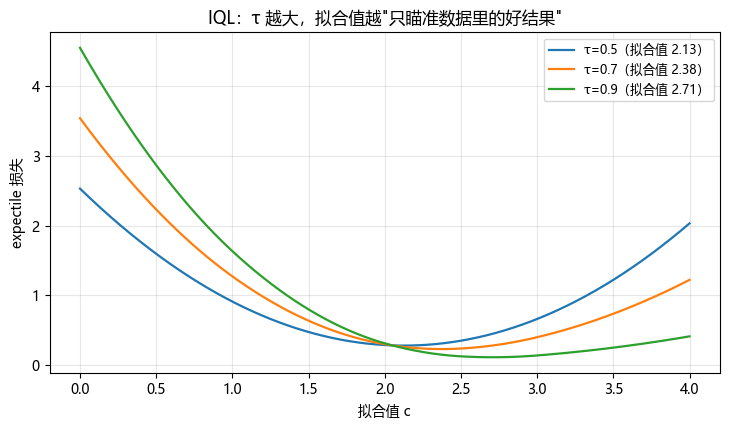

τ=0.5 → 拟合值 2.13
τ=0.7 → 拟合值 2.38
τ=0.9 → 拟合值 2.71
→ IQL 用分位数代替 max：乐观但有界，不发明 OOD 动作（无外推误差的自举）


In [4]:
# ========== IQL 的 expectile 回归：τ 越大越"只学好动作" ==========
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
def exp_loss(c, targets, tau):
    err = targets - c
    w = np.where(err > 0, tau, 1 - tau)           # 不对称权重：τ>0.5 惩罚"低于数据"更多
    return (w * err ** 2).mean()

targets = np.array([1.0, 2.0, 2.5, 3.0])          # 数据里 (s,a) 的目标值
taus = [0.5, 0.7, 0.9]
cs = np.linspace(0, 4, 2000)
fig, ax = plt.subplots(figsize=(7.4, 4.4))
fits = []
for tau in taus:
    losses = np.array([exp_loss(c, targets, tau) for c in cs])
    fits.append(float(cs[np.argmin(losses)]))
    ax.plot(cs, losses, lw=1.6, label=f'τ={tau}（拟合值 {fits[-1]:.2f}）')
ax.set_xlabel('拟合值 c'); ax.set_ylabel('expectile 损失')
ax.set_title('IQL：τ 越大，拟合值越"只瞄准数据里的好结果"', fontsize=12)
ax.legend(fontsize=9); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()
for tau, v in zip(taus, fits):
    print('τ=%.1f → 拟合值 %.2f' % (tau, v))
assert fits[0] < fits[-1]
print('→ IQL 用分位数代替 max：乐观但有界，不发明 OOD 动作（无外推误差的自举）')

### 6.1 三方案对比精讲：BCQ / CQL / IQL 怎么选（🔴 背诵级）

**本节导读**：三大离线算法 = 三种"防外推"哲学。这一节给一张总表 +
选型决策树 + "离线→在线微调"的工程衔接。

**1. 三种哲学的对比（背表）**：
| | BCQ | CQL | IQL |
|---|---|---|---|
| 防外推手段 | 约束动作（生成器） | 压 OOD Q（损失） | 学数据内上分位（目标） |
| 策略形式 | 显式（候选+argmax） | 贪心于 Q（隐式） | 隐式（expectile） |
| 需要动作生成模型 | 是（VAE） | 否 | 否 |
| 实现复杂度 | 中（多模型） | 低（改损失） | 低（改损失） |
| 数据差时鲁棒性 | 中 | 中 | **高（首选）** |
| 连续/高维动作 | 好 | 好 | 好 |

**2. 决策树（面试快速答）**：
- 数据质量差 / 要稳妥 → **IQL**（对数据分布最不敏感）
- 需要确定性能上限 / 数据覆盖好 → **CQL**（上限高）
- 动作空间复杂且要强约束 → **BCQ**（生成模型严格限域）
- 统一建议：**先 IQL 试基线，再 CQL 提上限**

**3. 为什么 IQL"最稳"（深一层）**：BCQ/CQL 都依赖"Q 在数据内可信"
（CQL 还要调 β）；IQL 只要"数据内上分位方向"粗略对就行 → 对
Q 的绝对精度不敏感 → 数据参差时最不容易崩。

**4. 离线 → 在线微调（工程衔接，背）**：
- 先用离线数据训好（IQL/CQL）→ 再上线小步在线 RL
- 关键：**在线阶段别用大学习率把离线学到的冲掉**（低 α、小步）
- 常见两难：继续 off-policy 用回放（混合新旧数据）→ 数据分布渐移
  → 推荐"保守初始化 + 在线小步"（如 Cal-QL）

**5. 易错点**：
- "离线 RL" ≠ "用历史数据做回放在线训练"：离线是真·无交互
- 三方案都解决"外推误差"，但**不解决数据覆盖不足**（没采过的状态
  谁也救不了）——面试说"离线 RL 上限 = 数据覆盖"得分

**6. 面试问法**："离线 RL 三种方法区别？" → "BCQ 约束动作来源、
CQL 压 OOD Q、IQL 改学习目标（expectile 隐式乐观）；数据差选 IQL，
追求上限选 CQL，强约束选 BCQ。"

---


## 6. 三方案对比、离线→在线微调（🔴 背诵级）

| 方法 | 手段 | 一句话原理 | 适合 |
|---|---|---|---|
| **BCQ** | 策略显式约束 | 动作锁在行为数据 ε-球内 | 数据覆盖较全 |
| **CQL** | 值函数保守化 | 压低 OOD 的 Q | 数据覆盖一般 |
| **IQL** | 分位数回归 | 只学数据内"好"的 (s,a) | 数据质量参差 |

**Offline → Online 微调**：先用离线数据练到"能用"，再少量在线交互修正——
这是业界实际落地套路（如机器人：先看录像，再小范围真机试），注意微调初期要给策略"保鲜"
（参考 BCQ 式的约束，防止一上台就崩）。

---

## 7. 数字敏感度与易错点

- **分布偏移**：学到的策略 ≠ 行为策略 → 动作出圈 → 外推误差
- **CQL 正则系数 α**：太大→Q 太保守（不敢动）；太小→等于在线 Q-learning（崩）
- **IQL 的 τ**：通常 0.7~0.9；τ=0.5 退化成期望回归（普通 TD 风格）
- 易错：**离线 RL 不是"少探索的在线 RL"**——数据是**静态的**，探索完全无效
- 易错：**回放缓冲里的旧数据 ≠ 离线数据集**——在线时策略还在演化，数据是"活的"

## 8. 面试速答（30 秒背诵版）

1. **Q：离线 RL 和在线 RL 区别？** A：数据固定、不能试错，难点从探索变为分布偏移
2. **Q：外推误差是什么？** A：OOD 动作的 Q 无依据高估，策略专挑虚高动作，越学越偏
3. **Q：BCQ 怎么做？** A：生成器 + ε-球约束，argmax 只在行为数据附近进行
4. **Q：CQL 目标公式？** A：$\alpha \mathbb{E}_\mu[Q] - \mathbb{E}_\mathcal{D}[Q] + \text{TD}$，压 OOD 抬数据内
5. **Q：IQL 怎么做？** A：expectile 回归（不对称平方损失），只学数据内上分位，不碰 max
6. **Q：三个方法选型？** A：BCQ 约束动作、CQL 保守值、IQL 分位数——按数据质量选

## 9. 知识链自测

- [ ] 能手推：CQL 目标的两项拉锯；IQL 的 expectile 损失
- [ ] 能对比：BCQ vs CQL vs IQL；离线 RL vs 在线 RL vs model-based
- [ ] 能默写：CQL 正则式、expectile 损失式
- [ ] 全模块闭环：00-11 篇串起来 = MDP → DP/MC/TD → Q/DQN → PG/AC → PPO/GRPO → DDPG/TD3/SAC
  → MARL → Model-based → Offline —— 这就是 RL 从入门到前沿的整条知识链。